**Experiment 1 : Exploratory Data Analysis**

**OBJECTIVES:**


*  To perform comprehensive Exploratory Data Analysis (EDA) on a tabular dataset using statistical summaries and visual representations.
*  To identify data distributions, detect missing values, and evaluate potential outliers across continuous and categorical attributes.
* To assess mathematical model assumptions—such as normality, linearity, and multicollinearity—to select appropriate feature scaling techniques and machine learning algorithms.

In [ ]:
#Importing the required packages
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Loading of the IRIS dataset
df=pd.read_csv("iris.csv",header=None, names=["sepal length in cm","sepal width in cm","petal length in cm","petal width in cm","class"])
print("DATASET LOADED SUCCESSFULLY")

#To know information about the dataset
print("-----------------------------------------------------")
print("               ABOUT THE DATASET                     ")
print("-----------------------------------------------------")
print("")
print("\nShape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print(" ")
print("\nData Types:")
print(df.dtypes)
print(" ")
print("\nFirst 5 Rows")
print(df.head())
print(" ")
#To know about the number of missing columns in the dataset
print("\nMissing Values")
missing = df.isnull().sum()
missing_percent = (missing/len(df))*100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

print(missing_df)

DATASET LOADED SUCCESSFULLY
-----------------------------------------------------
               ABOUT THE DATASET                     
-----------------------------------------------------


Shape: (150, 5)

Columns:
['sepal length in cm', 'sepal width in cm', 'petal length in cm', 'petal width in cm', 'class']
 

Data Types:
sepal length in cm    float64
sepal width in cm     float64
petal length in cm    float64
petal width in cm     float64
class                  object
dtype: object
 

First 5 Rows
   sepal length in cm  sepal width in cm  petal length in cm  \
0                 5.1                3.5                 1.4   
1                 4.9                3.0                 1.4   
2                 4.7                3.2                 1.3   
3                 4.6                3.1                 1.5   
4                 5.0                3.6                 1.4   

   petal width in cm        class  
0                0.2  Iris-setosa  
1                0.2  Iris-setosa 

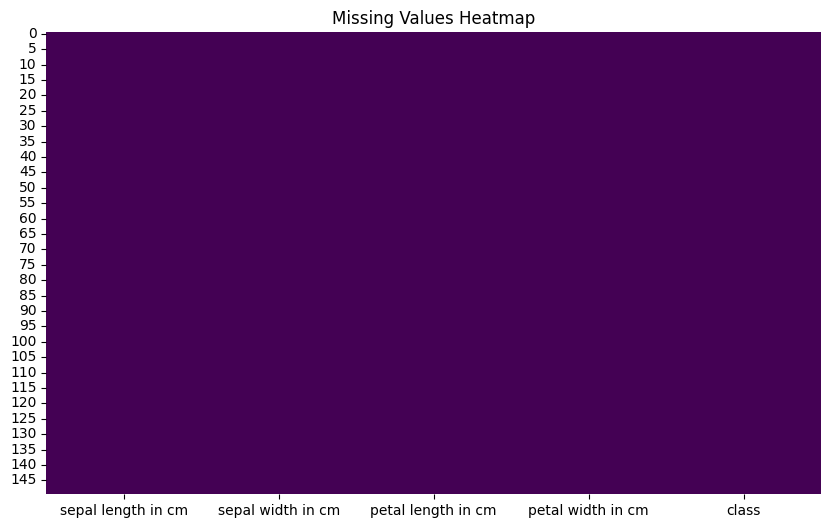

In [ ]:
#HeatMap to demonstrate missing values in the dataset
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

The uniform purple display across all 150 instances and 5 attributes (sepal length, sepal width, petal length, petal width, and class) indicates a 0% missing rate in the Iris dataset. With zero null values detected (NaN = 0), no row removal or imputation steps (such as mean, median, or KNN imputation) are required before feature scaling and model training.

In [ ]:
#Finding all the columns and listing the columns with numerical data and categorical data

raw_num_cols = df.select_dtypes(include=np.number).columns.tolist()
raw_cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
binary_cols = [col for col in raw_num_cols if df[col].nunique(dropna=True) <= 2]
true_num_cols = [col for col in raw_num_cols if col not in binary_cols]
true_cat_cols = raw_cat_cols + binary_cols
print("Continuous Numerical Columns:", true_num_cols)
print("Categorical & Binary Columns:", true_cat_cols)

Continuous Numerical Columns: ['sepal length in cm', 'sepal width in cm', 'petal length in cm', 'petal width in cm']
Categorical & Binary Columns: ['class']


**Numerical Statistics**

In [ ]:
#Descriptive analysis (mean, median, mode,etc)
print("\nNumerical Statistics")
print(df.describe())

print("\nCategorical Statistics")
print(df.describe(include='object'))



Numerical Statistics
       sepal length in cm  sepal width in cm  petal length in cm  \
count          150.000000         150.000000          150.000000   
mean             5.843333           3.054000            3.758667   
std              0.828066           0.433594            1.764420   
min              4.300000           2.000000            1.000000   
25%              5.100000           2.800000            1.600000   
50%              5.800000           3.000000            4.350000   
75%              6.400000           3.300000            5.100000   
max              7.900000           4.400000            6.900000   

       petal width in cm  
count         150.000000  
mean            1.198667  
std             0.763161  
min             0.100000  
25%             0.300000  
50%             1.300000  
75%             1.800000  
max             2.500000  

Categorical Statistics
              class
count           150
unique            3
top     Iris-setosa
freq             5

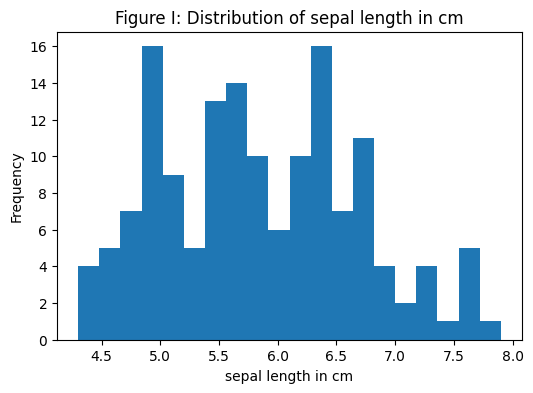

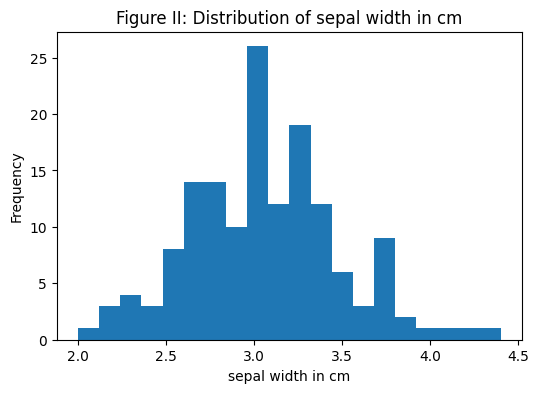

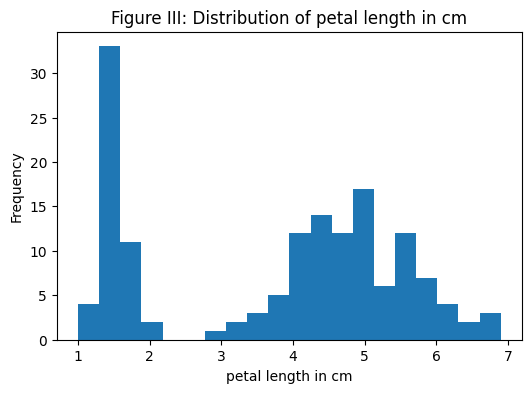

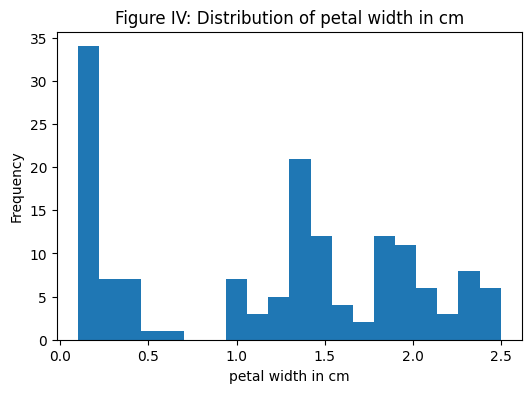

In [ ]:
#We use histogram to see the distribution of numerical data depending on the shape of the graph
num_cols = df.select_dtypes(include=np.number).columns

# Roman numerals for figure names
roman_numerals = ["I", "II", "III", "IV", "V", "VI", "VII", "VIII", "IX", "X"]

for i, col in enumerate(num_cols):
    plt.figure(figsize=(6, 4))

    plt.hist(df[col].dropna(), bins=20)

    plt.title(f"Figure {roman_numerals[i]}: Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

**Interpretation for Figure I:**

The distribution exhibits a bimodal (two-peaked) pattern centered around 5.0 cm and 6.4 cm, ranging from 4.3 cm to 7.9 cm. This suggests underlying class clusters, making distance-based or non-linear models preferable over simple linear assumptions.

**Interpretation for Figure II:**

The feature exhibits an approximately normal (bell-shaped) distribution centered at ~3.0 cm, with data spread symmetrically between 2.0 cm and 4.4 cm. Because it satisfies normality, this feature is well-suited for standardization
 (μ=0,σ=1) and linear model assumptions.

**Interpretation for Figure III:**

The histogram displays a strongly bimodal distribution split into two clear clusters separated by an empty gap between $2.2\text{ cm}$ and $3.0\text{ cm}$. The first sharp peak occurs at 1.0–1.8 cm, while a second broader group spans 3.0–6.9 cm. This clear separation makes petal length a key discriminative feature for clustering and classification models.

**Interpretation for Figure IV:**

The histogram reveals a strong bimodal distribution featuring an empty gap between 0.7 cm and 0.9 cm where no observations exist. Data points are heavily concentrated in a sharp peak at 0.1–0.4 cm and a wider cluster from 1.0 cm to 2.5 cm. This distinct grouping makes petal width another highly informative, discriminative feature for classification algorithms.

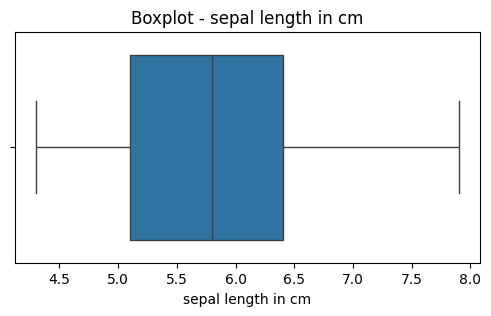

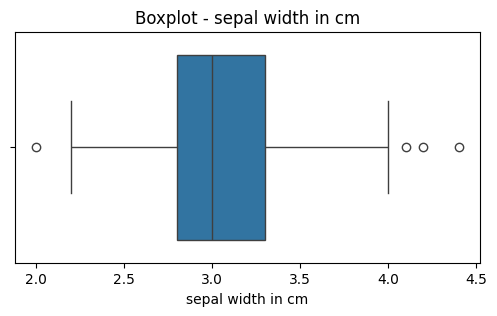

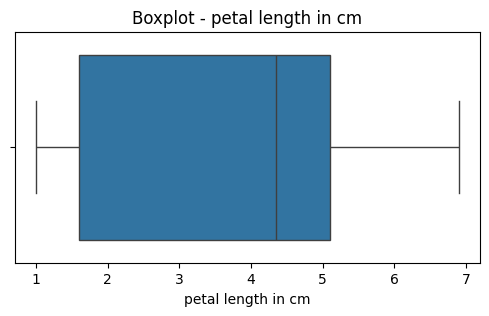

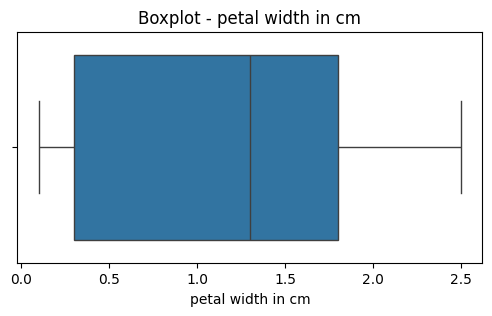

In [ ]:
#Boxplots are used to detect the outliers in the dataset
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

**Interpretation (Boxplot - Sepal Length):**


*   **No Outliers:** All data points fall within
the calculated Interquartile Range (1.5×IQR) whiskers, confirming an absence of univariate outliers.
*   **Symmetry & Spread:** The median line sits centrally near 5.8 cm, with the middle 50% of data (IQR) spanning between 5.1 cm and 6.4 cm, indicating a balanced spread without extreme skewness.

**Interpretation (Boxplot - Sepal Width):**


* **Presence of Outliers:** Unlike other features,
sepal width contains 4 univariate outliers—one below $2.2\text{ cm}$ ($\approx 2.0\text{ cm}$) and three above $4.0\text{ cm}$ ($\approx 4.1\text{ cm}, 4.2\text{ cm}, 4.4\text{ cm}$).

**Interpretation (Boxplot - Petal Length):**


*  **Zero Outliers:** No data points appear beyond the whiskers, confirming an absence of outliers.
*   **Asymmetric Spread:** The median sits shifted to the right ($\approx 4.35\text{ cm}$), with a wide Interquartile Range (IQR) spanning $1.6\text{ cm}$ to $5.1\text{ cm}$. This asymmetry reflects the distinct underlying species clusters rather than a single centered distribution.

**Interpretation (Boxplot - Petal Width):**


*   **Zero Outliers:** All observations lie strictly within the calculated whisker boundaries, confirming an absence of outliers.
*   **Distribution & Spread:** The median sits at $\approx 1.3\text{ cm}$, with an Interquartile Range (IQR) extending from $0.3\text{ cm}$ to $1.8\text{ cm}$. The slightly longer upper whisker reflects a mild right-skewed profile, driven by the larger petal measurements of the Virginica species.






In [ ]:
#Finding the outlier using the IQR method
print("\nOutlier Report")

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")



Outlier Report
sepal length in cm: 0 outliers
sepal width in cm: 4 outliers
petal length in cm: 0 outliers
petal width in cm: 0 outliers


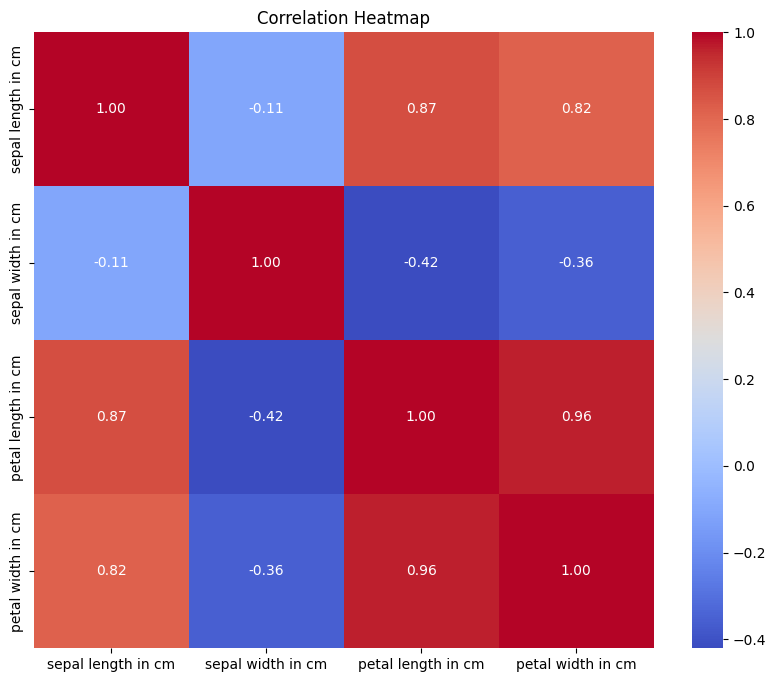

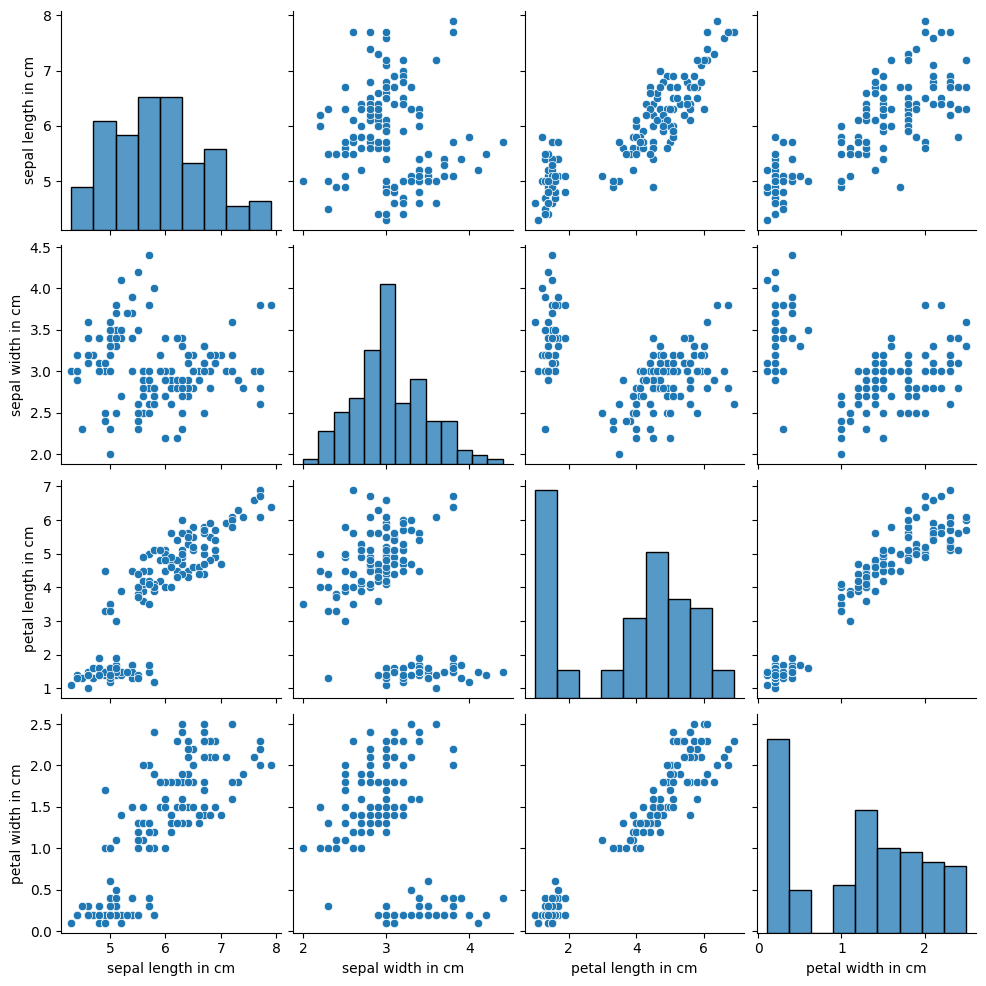

In [ ]:
# -----------------------------------------------------
# Correlation Matrix
# -----------------------------------------------------
if len(num_cols) > 1:
    plt.figure(figsize=(10,8))
    corr = df[num_cols].corr()

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )

    plt.title("Correlation Heatmap")
    plt.show()

# -----------------------------------------------------
# Pairplot
# -----------------------------------------------------
if len(num_cols) > 1:
    sns.pairplot(df[num_cols[:5]])
    plt.show()

 A correlation heatmap is a visual matrix that computes and displays the linear correlation coefficient (usually Pearson's correlation, $r$) between every pair of numerical features in your dataset.

In [ ]:
#Skewness to know how far the distribution is moved away from the center
if len(num_cols) > 0:
    print("\nSkewness")
    print(df[num_cols].skew())


Skewness
sepal length in cm    0.314911
sepal width in cm     0.334053
petal length in cm   -0.274464
petal width in cm    -0.104997
dtype: float64


In [ ]:
#Overall ANalysis of the dataset
print("EDA SUMMARY")
print("="*60)
cat_cols = df.select_dtypes(exclude=np.number).columns
print(f"Rows               : {df.shape[0]}")
print(f"Columns            : {df.shape[1]}")
print(f"Numerical Features : {len(num_cols)}")
print(f"Categorical Features: {len(cat_cols)}")

if missing.sum() == 0:
    print("Missing Values     : None")
else:
    print("Missing Values Present")

print("\nPotential Highly Correlated Features")

if len(num_cols) > 1:
    corr = df[num_cols].corr()

    for i in range(len(corr.columns)):
        for j in range(i):
            if abs(corr.iloc[i,j]) > 0.8:
                print(
                    corr.columns[i],
                    "<-->",
                    corr.columns[j],
                    "=",
                    round(corr.iloc[i,j],2)
                )

EDA SUMMARY
Rows               : 150
Columns            : 5
Numerical Features : 4
Categorical Features: 1
Missing Values     : None

Potential Highly Correlated Features
petal length in cm <--> sepal length in cm = 0.87
petal width in cm <--> sepal length in cm = 0.82
petal width in cm <--> petal length in cm = 0.96
